<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day14_practice3_XAI_GradCAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# GradCAM은 CNN이 이미지를 보고 "어느 부분을 보고 이 클래스로 판단했는가?"를 시각적으로 보여주는 기
# XAI (설명 가능한 인공지능)는 AI가 왜 그런 판단을 내렸는지 사람이 이해할 수 있도록 설명해주는 기술

# CNN의 Gradient와 Feature Map을 이용하여 모델의 특정 클래스 예측에 영향을 준 영역을 hitmap

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F # 신경망에서 쓰는 함수를 모아둔 모듈
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# 셀 1. 준비
def load_fmnist(root="./data"):
  tf = transforms.ToTensor()
  tr = datasets.FashionMNIST(root=root, train=True, download=True, transform=tf)
  te = datasets.FashionMNIST(root=root, train=False, download=True, transform=tf)
  return tr, te

train_data, test_data = load_fmnist()
classes = train_data.classes

class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
    self.conv2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU()) # ← CAM 대상
    self.pool2 = nn.MaxPool2d(2)
    self.head = nn.Sequential(nn.Flatten(), nn.Linear(32*7*7, 128), nn.ReLU(), nn.Linear(128, 10))

  def forward(self, x):
    self.fmap = self.conv2(self.conv1(x))
    return self.head(self.pool2(self.fmap))

model = CNN().to(device)
loader = DataLoader(train_data, batch_size=256, shuffle=True)
loss_fn, opt = nn.CrossEntropyLoss(), torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(2):
  for x, y in loader:
    x, y = x.to(device), y.to(device)
    loss = loss_fn(model(x), y)
    opt.zero_grad()
    loss.backward()
    opt.step()

print(f"준비 완료 (2 epoch, loss {loss.item():.3f})")


100%|██████████| 26.4M/26.4M [00:01<00:00, 21.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 341kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.35MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.8MB/s]


준비 완료 (2 epoch, loss 0.358)


In [9]:
# 셀 2. Grad-CAM
# 마지막 conv2d 의 특징맵
# 그 특징맵에 대한 점수의 기울기(gradient)
# Grad-CAM = Σ (기울기로 잰 중요도 × 특징맵) → 주목 히트맵
# 이 사진을 '셔츠'라고 판단할 때, 어느 위치가 근거였나?

def grad_cam(model, image, target_class=None):
  model.eval()
  image = image.unsqueeze(0).to(device) # (1,28,28) → (1,1,28,28) 배치차원 추가
  logits = model(image)     # 순전파 실행 결과 점수, 특징맵이 저장됨 (model.fmap)
  if target_class is None:
    target_class = logits.argmax(1).item() # 모델이 고른 최고점 클래스로
  model.zero_grad()
  fmap = model.fmap # 저장해둔 특징맵 (1, 32, 14, 14)
  fmap.retain_grad() # 기울기를 남겨둬라
  logits[0, target_class].backward() # 0번 이미지, 클래스 점수 # 내가 설명하려는 최고점 클래스의 점수 하나만 역전파를 해라. 기울기 계산해라.

  weights = fmap.grad.mean(dim=(2,3), keepdim=True) # fmap.grad()는 (1,32,14,14) -> 위치마다 기울기가 다르다. dim=(2,3)은 H W 방향으로 평균 내면 '지도 1장당 대표 중요도 1개'
  # weights =  이 지도가 전체적으로 판단에 얼마나 기여했나를 하나의 숫자로 요약
  cam = F.relu((weights * fmap).sum(dim=1)) # weights*fmap = 각 지도에 중요도를 곱함 -> 중요한 지도는 강조, 안 중요한 지도는 약화
  cam = F.interpolate(cam.unsqueeze(0), size=image.shape[2:], mode="bilinear")[0,0] # cam 은 14x14 -> 원본 이미지 28x28, interpolate = 크기 조절(업샘플)
  cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8) # 값을 0-1 범위로 정규화, 히트맵 색을 일정하게 그리기 쉬움
  return cam.detach().cpu(), target_class, logits.softmax(1)[0, target_class].item() # 히트맵으로 그릴 값, 예측 클래스 번호, 그 클래스의 확률


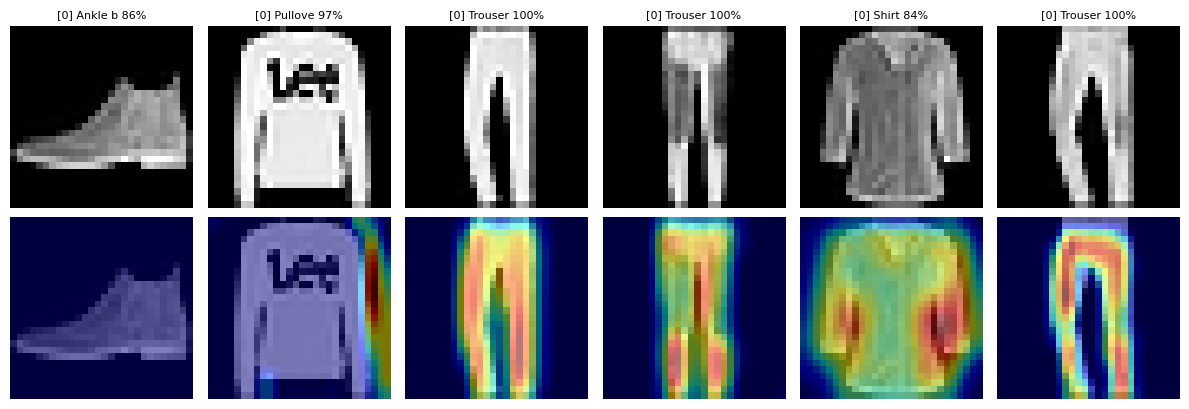

In [11]:
# 셀 3. 정답
fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))
for i in range(6):
  img, label = test_data[i]
  cam, pred, conf = grad_cam(model, img)
  ck = "0" if pred == label else "X"
  # 원본 이미지 + 제목
  axes[0, i].imshow(img[0], cmap="gray")
  axes[0, i].set_title(f"[{ck}] {classes[pred][:7]} {conf:.0%}", fontsize=8)

  # 원본 위에 히트맵을 겹쳐서 '어디를 봤나' 표시
  axes[1, i].imshow(img[0], cmap="gray")
  axes[1, i].imshow(cam, cmap="jet", alpha=0.5)

  for r in range(2):
    axes[r, i].axis("off")

plt.tight_layout()
plt.savefig("plot1_gradcam.png")
plt.show()

In [12]:
# 셀 4. 오답 검진
wrongs = []
test_loader = DataLoader(test_data, batch_size=512)
model.eval()
with torch.no_grad():
  for x, y in test_loader:
    preds = model(x.to(device)).argmax(1).cpu() # 각 이미지 예측의 최고점 클래스
    for img, t, p in zip(x,y, preds):
      if t != p:
        wrongs.append((img, t.item(), p.item()))
      if len(wrongs) >= 4: # 오답이 4개만
        break

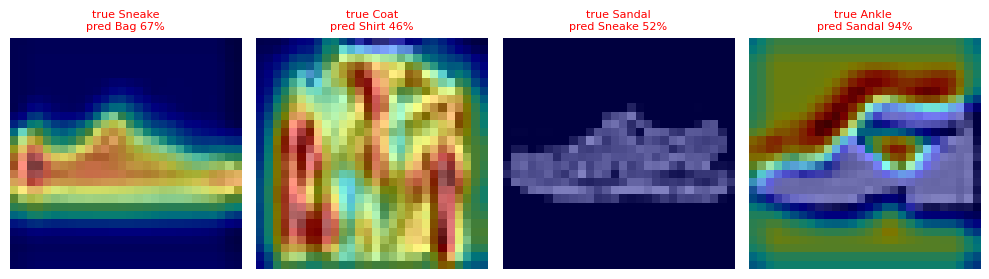

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(10, 2.8))
for ax, (img, t, p) in zip(axes, wrongs[:4]):
  cam, _, conf = grad_cam(model, img, target_class=p)
  ax.imshow(img[0], cmap="gray")
  ax.imshow(cam, cmap="jet", alpha=0.5)
  ax.set_title(f"true {classes[t][:6]}\npred {classes[p][:6]} {conf:.0%}", fontsize=8, color="red")
  ax.axis("off")
plt.tight_layout()
plt.savefig("plot2_wrong_gaze.png")
plt.show()